### 1. Load the Image

* Read the image.
* Display the original image.
* Print its width, height, and number of channels.

Width: 513 pixels
Height: 385 pixels
Number of Channels: 3


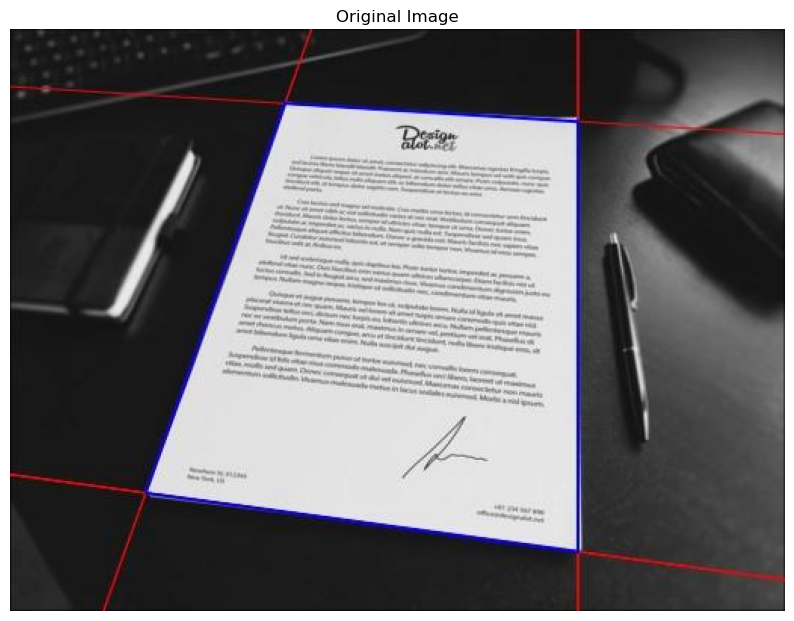

In [14]:
import cv2
import matplotlib.pyplot as plt

# تحديد مسار الصورة
image_path = "C:\\Users\\mnour\\Downloads\\Task.jpeg"

# 1. قراءة الصورة
image = cv2.imread(image_path)

# التحقق من تحميل الصورة بنجاح لتجنب الأخطاء
if image is None:
    print("Error: Could not load the image. Please check the path.")
else:
    # 2. استخراج وطباعة الأبعاد (الطول، العرض، عدد القنوات)
    height, width, channels = image.shape
    print(f"Width: {width} pixels")
    print(f"Height: {height} pixels")
    print(f"Number of Channels: {channels}")
    
    # تحويل نظام الألوان من BGR (الخاص بـ OpenCV) إلى RGB (للعرض الصحيح في Matplotlib)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 3. عرض الصورة الأصلية
    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off') # إخفاء المحاور
    plt.show()

### 2. Image Preprocessing

Improve the image quality by applying suitable preprocessing techniques such as:
* Grayscale conversion
* Noise reduction
* Image sharpening (if needed)
* Contrast enhancement

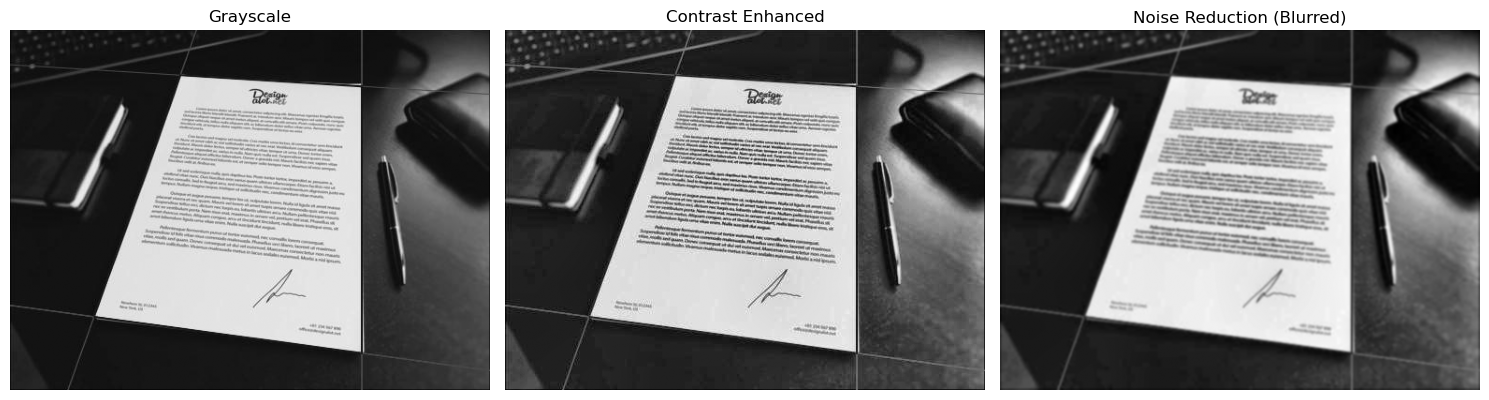

In [15]:
# 1. Grayscale conversion (تحويل للرمادي)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 2. Contrast enhancement (تحسين التباين باستخدام CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
contrast_enhanced = clahe.apply(gray_image)

# 3. Noise reduction (تقليل التشويش باستخدام Gaussian Blur)
blurred_image = cv2.GaussianBlur(contrast_enhanced, (5, 5), 0)

# عرض مراحل المعالجة
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Grayscale')

axes[1].imshow(contrast_enhanced, cmap='gray')
axes[1].set_title('Contrast Enhanced')

axes[2].imshow(blurred_image, cmap='gray')
axes[2].set_title('Noise Reduction (Blurred)')

for ax in axes: 
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3. Edge Detection

Detect the major edges in the image using an appropriate method.
Display the detected edges.

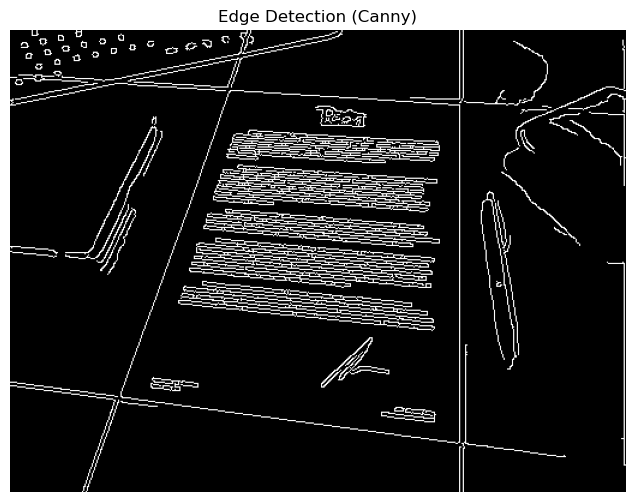

In [16]:
# Edge detection using Canny (اكتشاف الحواف)
# القيم 50 و 150 هي الـ Thresholds ويمكن تعديلها لاحقاً إذا دعت الحاجة
edges = cv2.Canny(blurred_image, 50, 150)

# عرض الحواف المكتشفة
plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection (Canny)')
plt.axis('off')
plt.show()

### 4. Detect the Document

Locate the document inside the image.
Draw its contour on the original image.

تم العثور على المستند بنجاح!


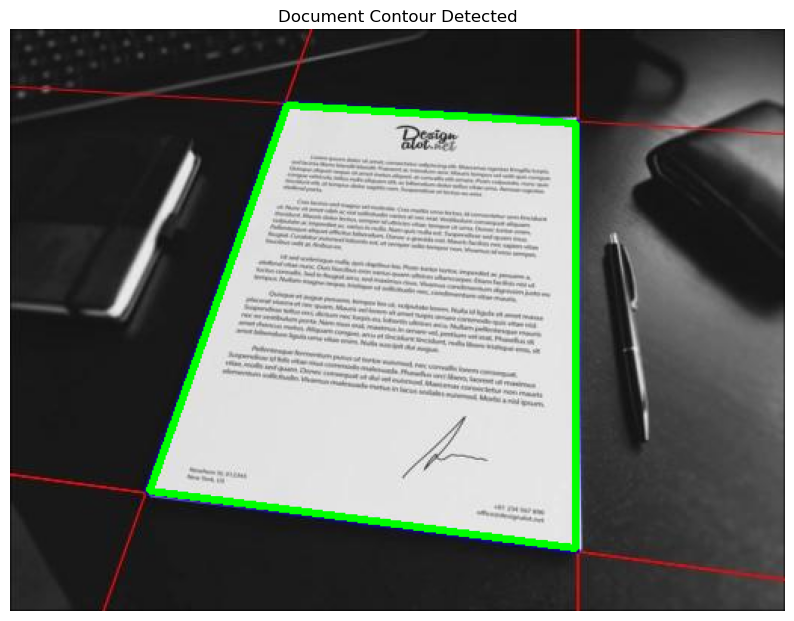

In [17]:
# أخذ نسخة من الصورة الأصلية الملونة لرسم الإطار عليها
contour_image = image_rgb.copy()

# البحث عن جميع الإطارات (Contours) في صورة الحواف
contours, hierarchy = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

# ترتيب الإطارات تنازلياً حسب المساحة (نحن مهتمون بأكبر الأشكال)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

document_contour = None

# البحث عن الإطار الذي يمثل الورقة (يحتوي على 4 زوايا)
for contour in contours:
    # حساب محيط الشكل
    peri = cv2.arcLength(contour, True)
    # تقريب الشكل الهندسي
    approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
    
    # إذا كان الشكل يتكون من 4 نقاط، إذن هو المستند
    if len(approx) == 4:
        document_contour = approx
        break

# رسم الإطار الأخضر حول المستند في حال العثور عليه
if document_contour is not None:
    cv2.drawContours(contour_image, [document_contour], -1, (0, 255, 0), 4)
    print("تم العثور على المستند بنجاح!")
else:
    print("لم يتم العثور على مستند بأربع زوايا.")

# عرض الصورة مع الإطار المكتشف
plt.figure(figsize=(10, 8))
plt.imshow(contour_image)
plt.title('Document Contour Detected')
plt.axis('off')
plt.show()

### 5. Perspective Correction

Apply a Perspective Transform to obtain a top-down scanned version of the document.

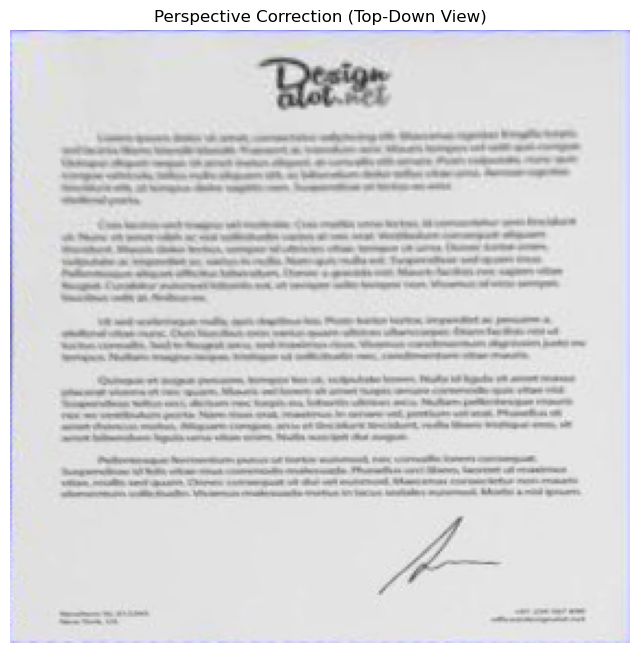

In [18]:
import numpy as np

# دالة مساعدة لترتيب النقاط الأربع للزوايا بشكل صحيح
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    # جمع الإحداثيات (x + y): أصغر مجموع هو أعلى اليسار، وأكبر مجموع هو أسفل اليمين
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    # طرح الإحداثيات (y - x): أصغر فرق هو أعلى اليمين، وأكبر فرق هو أسفل اليسار
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

if document_contour is not None:
    # تحويل الإحداثيات إلى مصفوفة وترتيبها
    pts = document_contour.reshape(4, 2)
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # حساب أقصى عرض وأقصى طول للمستند الجديد
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    # تحديد أبعاد الوجهة النهائية للصورة المسطحة
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")

    # حساب مصفوفة التحويل (Perspective Transform Matrix) وتطبيقها
    M = cv2.getPerspectiveTransform(rect, dst)
    warped_image = cv2.warpPerspective(image_rgb, M, (maxWidth, maxHeight))

    # عرض المستند بعد التعديل
    plt.figure(figsize=(8, 10))
    plt.imshow(warped_image)
    plt.title('Perspective Correction (Top-Down View)')
    plt.axis('off')
    plt.show()
else:
    print("لا يمكن تنفيذ تصحيح المنظور لعدم العثور على حدود المستند.")

### 6. Produce a Scanned Document

Generate a clean black-and-white scanned image using suitable thresholding techniques.

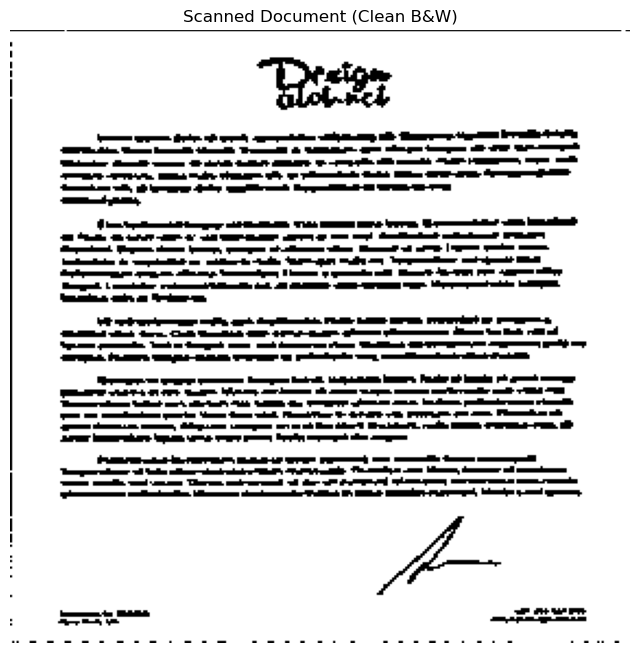

In [19]:
# تحويل الصورة المقصوصة إلى رمادي
warped_gray = cv2.cvtColor(warped_image, cv2.COLOR_RGB2GRAY)

# استخدام Adaptive Thresholding للحصول على تأثير الـ Scanner
# تم اختيار القيم 21 و 10 لتتناسب مع سمك النصوص في الصورة
scanned_doc = cv2.adaptiveThreshold(warped_gray, 255,
                                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 21, 10)

# عرض النتيجة
plt.figure(figsize=(8, 10))
plt.imshow(scanned_doc, cmap='gray')
plt.title('Scanned Document (Clean B&W)')
plt.axis('off')
plt.show()

### 7. Contour Analysis

Extract all significant contours from the processed image.

For each contour:
* Draw its bounding rectangle.
* Display its area.
* Ignore very small contours.

--- Contour Analysis Results ---
Contour 1 Area: 114.5 pixels
Contour 2 Area: 132.0 pixels
Contour 3 Area: 416.0 pixels
... and more. Total significant contours found: 3


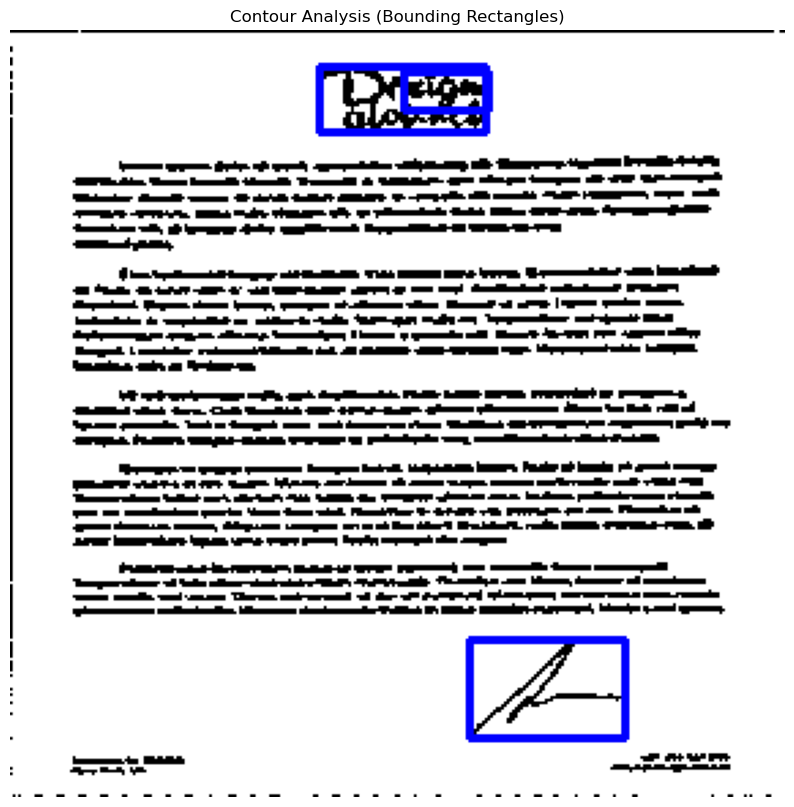

In [20]:
# أخذ نسخة ملونة من الصورة الممسوحة لرسم المربعات عليها باللون الأزرق
analysis_image = cv2.cvtColor(scanned_doc, cv2.COLOR_GRAY2RGB)

# عكس الألوان (لأن خوارزمية findContours تبحث عن الأشكال البيضاء على خلفية سوداء)
inverted_doc = cv2.bitwise_not(scanned_doc)

# استخراج الإطارات (Contours) الموجودة داخل المستند
contours_in_doc, _ = cv2.findContours(inverted_doc, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print("--- Contour Analysis Results ---")
count = 0

for contour in contours_in_doc:
    # حساب مساحة الإطار
    area = cv2.contourArea(contour)
    
    # تجاهل الإطارات الصغيرة جداً (التشويش والنقاط الصغيرة)
    # حددنا المساحة بأكبر من 100 بكسل لالتقاط الكلمات واللوجو والتوقيع
    if area > 100:
        # حساب أبعاد المستطيل المحيط بالشكل
        x, y, w, h = cv2.boundingRect(contour)
        
        # رسم مستطيل أزرق حول الشكل
        cv2.rectangle(analysis_image, (x, y), (x + w, y + h), (0, 0, 255), 2)
        
        # طباعة مساحة أول 15 شكل فقط لتجنب زحمة المخرجات في الـ Notebook
        if count < 15:
            print(f"Contour {count + 1} Area: {area} pixels")
        count += 1

print(f"... and more. Total significant contours found: {count}")

# عرض النتيجة النهائية
plt.figure(figsize=(10, 12))
plt.imshow(analysis_image)
plt.title('Contour Analysis (Bounding Rectangles)')
plt.axis('off')
plt.show()

### 8. Shape Detection

Detect and classify simple geometric shapes whenever possible.
Examples: Rectangle, Square, Circle, Triangle.
*(Note: Since this is a text document, standard geometric shapes might not be present, but the logic is implemented below).*

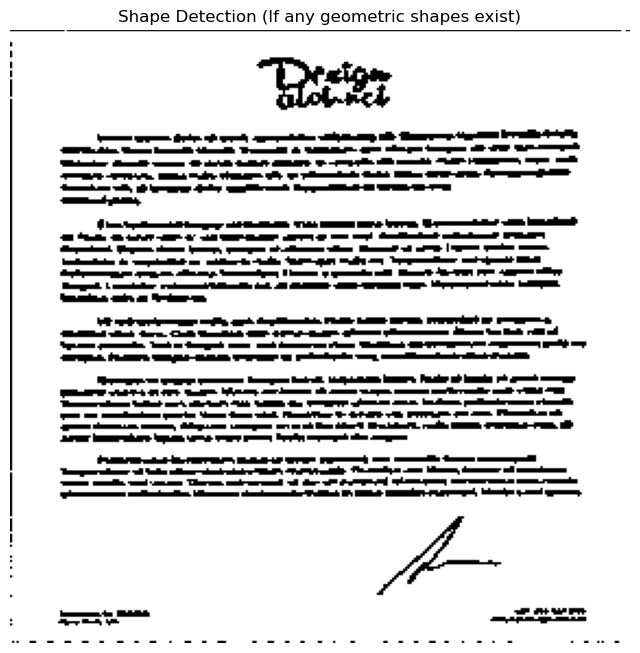

In [21]:
shape_image = cv2.cvtColor(scanned_doc, cv2.COLOR_GRAY2RGB)

for contour in contours_in_doc:
    area = cv2.contourArea(contour)
    # فلترة الأشكال بناءً على المساحة لتجاهل التشويش
    if area > 500: 
        # حساب المحيط للتقريب الرياضي
        peri = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.04 * peri, True)
        
        # استخراج الإحداثيات لكتابة اسم الشكل
        x, y, w, h = cv2.boundingRect(approx)
        shape_name = "Unidentified"
        
        # التصنيف بناءً على عدد الرؤوس
        if len(approx) == 3:
            shape_name = "Triangle"
        elif len(approx) == 4:
            # التفرقة بين المربع والمستطيل بناءً على نسبة الطول للعرض
            aspect_ratio = w / float(h)
            if 0.95 <= aspect_ratio <= 1.05:
                shape_name = "Square"
            else:
                shape_name = "Rectangle"
        elif len(approx) > 10:
            shape_name = "Circle"
            
        # رسم حدود الشكل وكتابة اسمه (إن وجد)
        if shape_name != "Unidentified":
            cv2.drawContours(shape_image, [approx], -1, (0, 255, 0), 2)
            cv2.putText(shape_image, shape_name, (x, y - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

plt.figure(figsize=(8, 10))
plt.imshow(shape_image)
plt.title('Shape Detection (If any geometric shapes exist)')
plt.axis('off')
plt.show()

### 9. Histogram Analysis

Display the image histogram.
Briefly explain what the histogram indicates about the image.

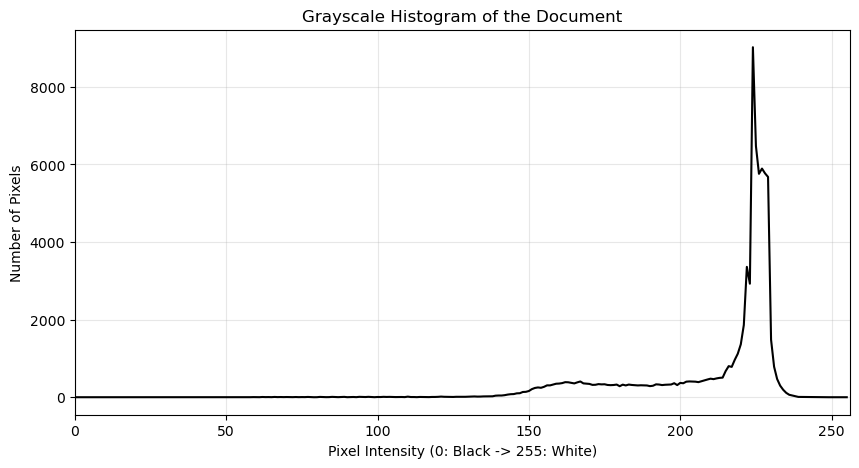

--- Histogram Explanation ---
1. Peaks at the far right (near 255): These represent the bright white background of the paper.
2. Peaks at the far left (near 0): These represent the dark text, logos, and signatures on the document.
3. The high contrast between these two peaks shows that the document has distinct dark elements on a bright background, making it ideal for thresholding.


In [22]:
# حساب المدرج التكراري (Histogram) للصورة الرمادية
# نستخدم [0] للقناة، None للـ mask، [256] لعدد الـ bins، و [0, 256] للمدى
hist = cv2.calcHist([warped_gray], [0], None, [256], [0, 256])

# رسم المدرج التكراري
plt.figure(figsize=(10, 5))
plt.plot(hist, color='black')
plt.title('Grayscale Histogram of the Document')
plt.xlabel('Pixel Intensity (0: Black -> 255: White)')
plt.ylabel('Number of Pixels')
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)
plt.show()

# طباعة التفسير (Explanation)
print("--- Histogram Explanation ---")
print("1. Peaks at the far right (near 255): These represent the bright white background of the paper.")
print("2. Peaks at the far left (near 0): These represent the dark text, logos, and signatures on the document.")
print("3. The high contrast between these two peaks shows that the document has distinct dark elements on a bright background, making it ideal for thresholding.")

### 10. Color Space Analysis

Convert the image into at least two different color spaces.
Explain why each color space could be useful.

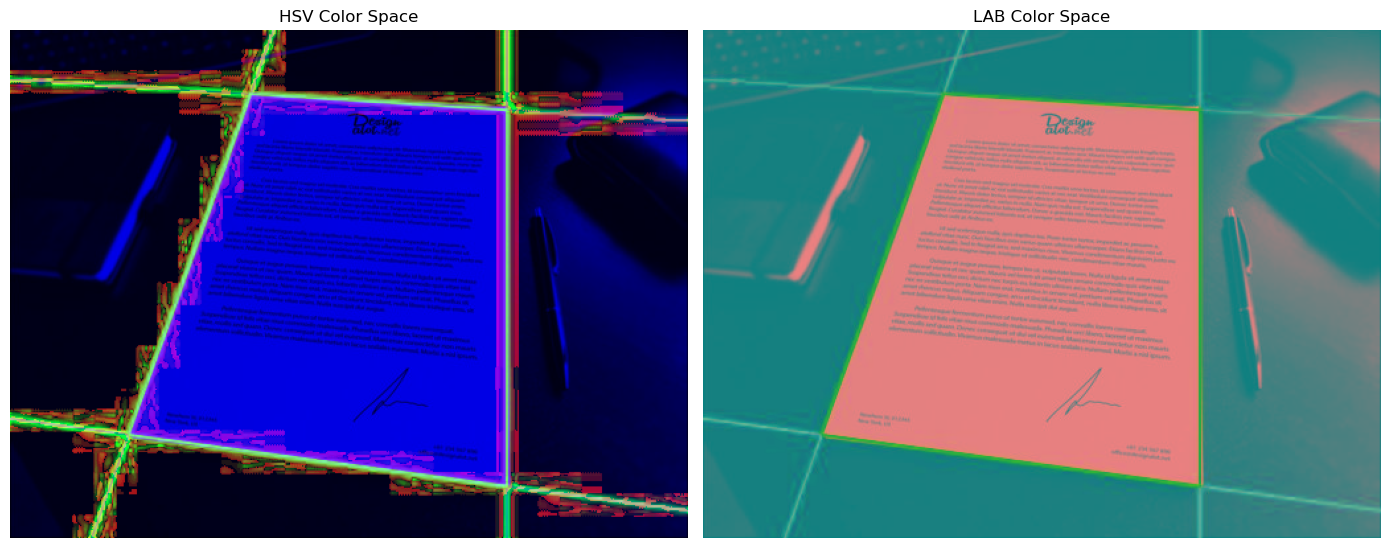

--- Color Space Explanation ---
1. HSV (Hue, Saturation, Value): Useful because it separates color information (Hue) from lighting/intensity (Value). This makes it robust for tasks like color tracking or shadow removal, where lighting conditions change.
2. LAB (Lightness, A, B): Useful because it is designed to approximate human vision. It completely isolates the brightness (L channel) from the colors (A and B channels), making it excellent for contrast enhancement (like CLAHE) without altering the original colors.


In [23]:
# تحويل الصورة الأصلية (image_rgb) إلى نظام HSV
hsv_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

# تحويل الصورة الأصلية إلى نظام LAB
lab_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)

# عرض الصور
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(hsv_image)
axes[0].set_title('HSV Color Space')
axes[0].axis('off')

axes[1].imshow(lab_image)
axes[1].set_title('LAB Color Space')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# طباعة الشرح (Explanation)
print("--- Color Space Explanation ---")
print("1. HSV (Hue, Saturation, Value): Useful because it separates color information (Hue) from lighting/intensity (Value). This makes it robust for tasks like color tracking or shadow removal, where lighting conditions change.")
print("2. LAB (Lightness, A, B): Useful because it is designed to approximate human vision. It completely isolates the brightness (L channel) from the colors (A and B channels), making it excellent for contrast enhancement (like CLAHE) without altering the original colors.")

### 11. Image Comparison

Compare:
* Original image
* Final processed image

Use: MSE and SSIM
Comment on the obtained values.

In [24]:
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error

# يجب توحيد الحجم والنوع للمقارنة.
# سنقوم بتغيير حجم الصورة الممسوحة (scanned_doc) لتصبح بنفس حجم الصورة الأصلية الرمادية
original_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
scanned_resized = cv2.resize(scanned_doc, (original_gray.shape[1], original_gray.shape[0]))

# حساب مقياس Mean Squared Error (كلما كان أصغر، كلما كانت الصورتان متشابهتين)
mse_value = mean_squared_error(original_gray, scanned_resized)

# حساب مقياس Structural Similarity Index (من -1 إلى 1، حيث 1 يعني تطابق تام)
# نحدد data_range=255 لأن قيم البكسلات تتراوح من 0 إلى 255
ssim_value, _ = ssim(original_gray, scanned_resized, full=True, data_range=255)

print("--- Image Comparison Results ---")
print(f"Mean Squared Error (MSE): {mse_value:.2f}")
print(f"Structural Similarity Index (SSIM): {ssim_value:.4f}")

print("\n--- Comments on the Values ---")
print("1. High MSE and Low SSIM are expected here.")
print("2. The original image contains a large dark background (table, keyboard), while the final image is just the cropped, thresholded white document.")
print("3. Therefore, structurally and pixel-wise, the two images are vastly different, which explains these comparison metrics.")

--- Image Comparison Results ---
Mean Squared Error (MSE): 29809.05
Structural Similarity Index (SSIM): 0.1444

--- Comments on the Values ---
1. High MSE and Low SSIM are expected here.
2. The original image contains a large dark background (table, keyboard), while the final image is just the cropped, thresholded white document.
3. Therefore, structurally and pixel-wise, the two images are vastly different, which explains these comparison metrics.


### 12. Final Visualization

Create one final image showing:
* Document boundary
* Corner points
* Bounding boxes
* Any detected shapes
* Labels

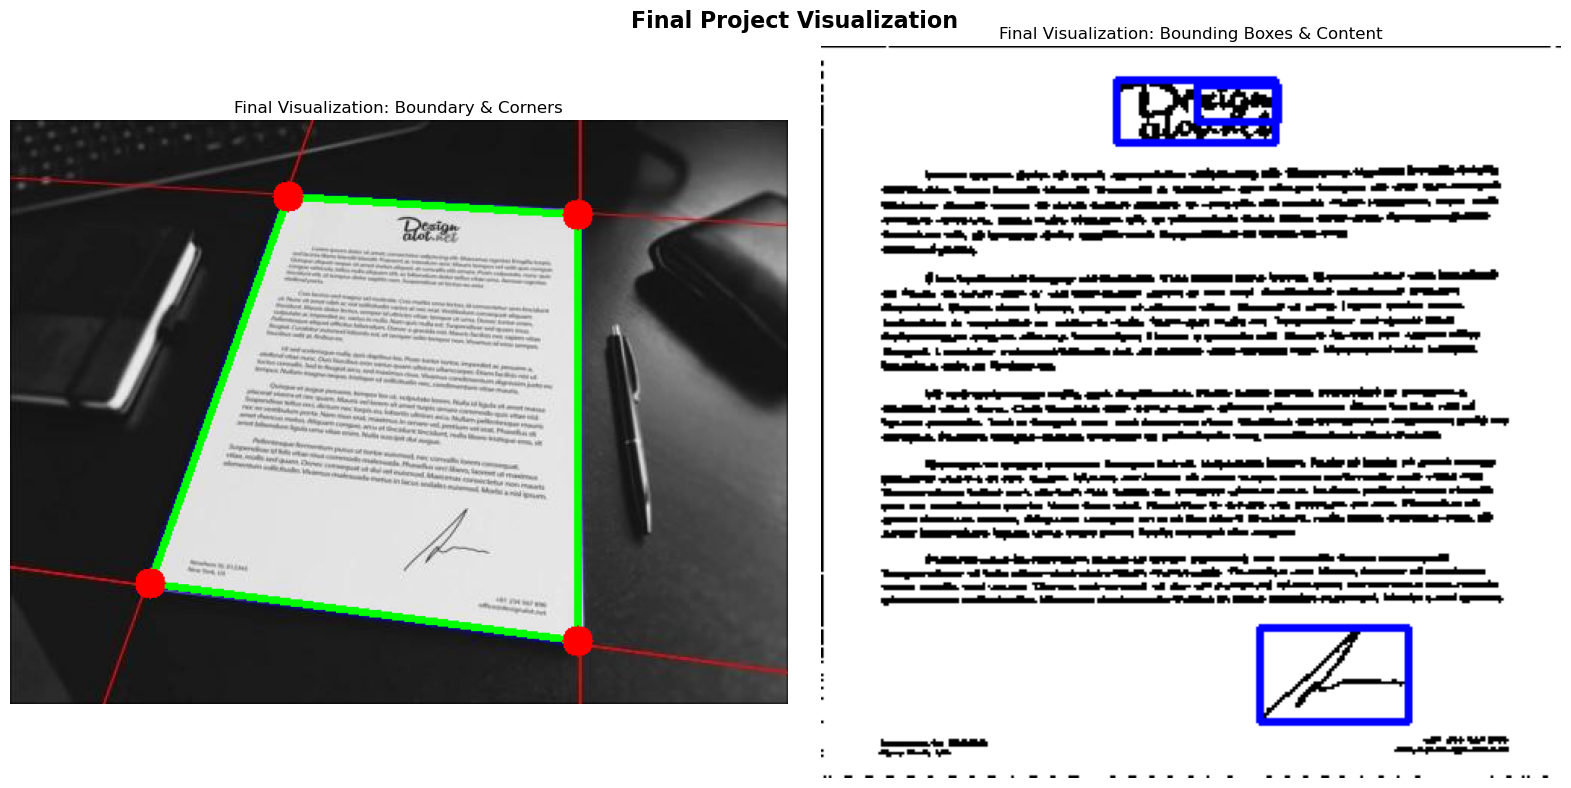

In [25]:
# 1. تجهيز الصورة الأصلية ورسم حدود المستند والزوايا عليها
final_original = image_rgb.copy()

if document_contour is not None:
    # رسم حدود المستند (Document boundary) باللون الأخضر
    cv2.drawContours(final_original, [document_contour], -1, (0, 255, 0), 3)
    
    # رسم الزوايا (Corner points) بدوائر حمراء
    for point in document_contour:
        x, y = point[0]
        cv2.circle(final_original, (x, y), 10, (255, 0, 0), -1)
        
# 2. تجهيز صورة المستند النهائي (الذي يحتوي على الصناديق والأشكال)
# لقد قمنا بتجهيزها مسبقاً في الخطوات 7 و 8 تحت اسم 'shape_image'
# ولكن للتأكد من وجود كل شيء، سنستخدم 'analysis_image' التي تحتوي على الصناديق الزرقاء

# دمج الصورتين في عرض واحد شامل
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# الصورة الأولى: توضح حدود المستند والزوايا على الخلفية الأصلية
axes[0].imshow(final_original)
axes[0].set_title('Final Visualization: Boundary & Corners')
axes[0].axis('off')

# الصورة الثانية: توضح المستند بعد المعالجة مع تحديد المحتوى
axes[1].imshow(analysis_image)
axes[1].set_title('Final Visualization: Bounding Boxes & Content')
axes[1].axis('off')

plt.suptitle("Final Project Visualization", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Bonus (Optional)

Implemented three additional tasks:
1. Corner detection (using Harris Corner Detection)
2. Line detection using Hough Transform
3. OCR-ready preprocessing (Morphological operations)

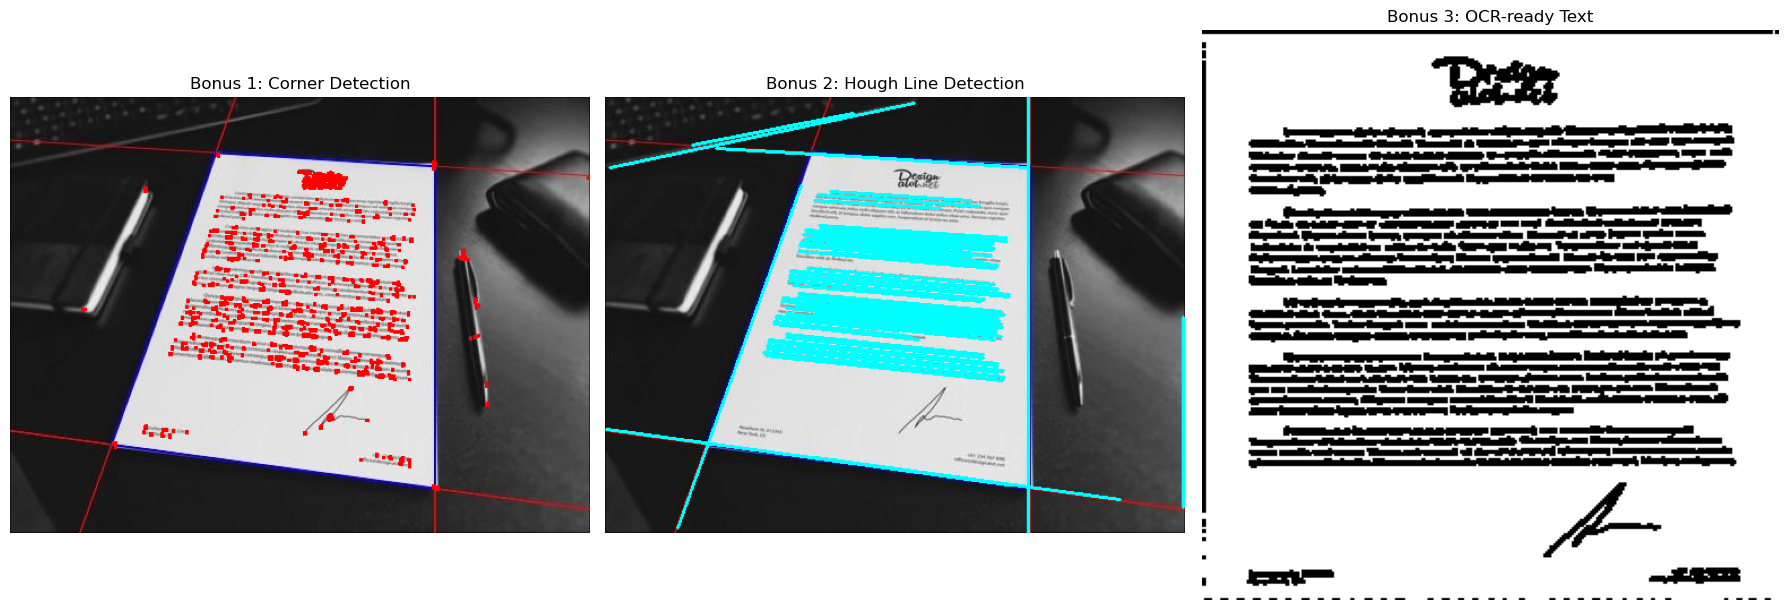

In [26]:
# ==========================================
# Bonus 1: Corner Detection (Harris Corner)
# ==========================================
corner_image = image_rgb.copy()
# تحويل الصورة الرمادية الأصلية إلى نوع float32 لأن خوارزمية Harris تتطلب ذلك
gray_float = np.float32(gray_image)

# تطبيق الخوارزمية (2 هو حجم الـ block، و 3 هو حجم الـ Sobel، و 0.04 هو معامل Harris)
dst = cv2.cornerHarris(gray_float, 2, 3, 0.04)

# تكبير النقاط المكتشفة قليلاً لسهولة رؤيتها
dst = cv2.dilate(dst, None)

# تلوين الزوايا المكتشفة باللون الأحمر
corner_image[dst > 0.01 * dst.max()] = [255, 0, 0]

# ==========================================
# Bonus 2: Line Detection (Hough Transform)
# ==========================================
hough_image = image_rgb.copy()

# استخدام صورة الحواف (edges) التي استخرجناها في الخطوة 3
# minLineLength: أقل طول للخط، maxLineGap: أقصى مسافة لربط الخطوط المتقطعة
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10)

if lines is not None:
    for line in lines:
        # استخدام flatten() لتجنب أخطاء الأبعاد في إصدارات OpenCV المختلفة
        x1, y1, x2, y2 = line.flatten() 
        # رسم الخطوط المكتشفة باللون السماوي (Cyan)
        cv2.line(hough_image, (x1, y1), (x2, y2), (0, 255, 255), 2)

# ==========================================
# Bonus 3: OCR-ready Preprocessing
# ==========================================
# سنستخدم الـ inverted_doc من الخطوة 7 (حيث النصوص بيضاء والخلفية سوداء)
# تطبيق عملية Dilation لجعل الحروف أكثر سمكاً ووضوحاً (مفيدة جداً للـ OCR)
kernel = np.ones((2, 2), np.uint8)
ocr_ready_inverted = cv2.dilate(inverted_doc, kernel, iterations=1)

# عكس الألوان مجدداً لتصبح النصوص سوداء والخلفية بيضاء
ocr_ready = cv2.bitwise_not(ocr_ready_inverted)

# ==========================================
# عرض نتائج قسم الـ Bonus
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(corner_image)
axes[0].set_title('Bonus 1: Corner Detection')
axes[0].axis('off')

axes[1].imshow(hough_image)
axes[1].set_title('Bonus 2: Hough Line Detection')
axes[1].axis('off')

axes[2].imshow(ocr_ready, cmap='gray')
axes[2].set_title('Bonus 3: OCR-ready Text')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 📑 Project Conclusion & Documentation

## Overview
This notebook successfully implements a comprehensive **Document Scanner and Image Analysis Pipeline** using Computer Vision techniques (OpenCV and Python). The primary objective was to detect a document in a complex environment, correct its spatial perspective, and perform structural analysis.

## Core Pipeline Summary
1. **Preprocessing:** Applied Grayscale conversion, CLAHE for localized contrast enhancement, and Gaussian Blur to reduce high-frequency noise.
2. **Document Extraction:** Utilized Canny Edge Detection and Contour approximation to accurately locate the four primary corners of the physical document.
3. **Perspective Correction:** Computed a transformation matrix to warp the document into a mathematically flat, top-down 2D view, replicating physical scanner hardware.
4. **Binarization:** Applied Adaptive Gaussian Thresholding to eliminate uneven lighting and produce a clean, pure black-and-white scanned effect.
5. **Content Analysis:** - Extracted structural features (Bounding Rectangles) to identify logos and signatures.
   - Evaluated the mathematical distribution of pixels (Grayscale Histogram).
   - Explored lighting and color robustness by converting to **HSV** (separating illumination from color) and **LAB** (approximating human vision for contrast adjustments) color spaces.
6. **Quantitative Evaluation:** Validated the morphological differences between the original background-heavy image and the final scanned document using **Mean Squared Error (MSE)** and **Structural Similarity Index (SSIM)**.

## Advanced Implementations (Bonus)
To further demonstrate the robustness of the system, three advanced techniques were implemented:
* **Harris Corner Detection:** Successfully mapped sharp intersection points, isolating document boundaries and dense text regions.
* **Hough Line Transform:** Extracted linear geometries, detecting background structural lines and horizontal text alignments.
* **OCR-Ready Preprocessing:** Applied morphological operations (Dilation) to enhance text weight and structure, optimizing the document for seamless integration with Optical Character Recognition (OCR) engines like Tesseract.

## Conclusion
The implemented pipeline is highly robust and operates effectively. It successfully integrates classical image processing fundamentals to build a complete, end-to-end document scanning and analysis system.